# 第41课 · 温柔地打开，清晰地看见——加窗（windowing）FFT 一条管线跑通，旁瓣应声而降

**目标**：跑通 **窗 → FFT → 旁瓣下降** 一条管线（`windowed_fft`）。

> **步骤 1-2-3**：截断会泄漏 → 乘 Hann 压旁瓣 → 看谱变干净。接口接 L36 窗、L40 读谱。

🔗 **Aurora 连接**：`aurora.audio.stft()` 在每帧调用加窗 FFT；`aurora/audio/windows.py` 提供 `hann`、`hamming` 等窗函数（window function），正是本节要接入的模块。

← **上一课**　[L40 · 频谱分析实战](L40_spectrum.ipynb)

> 上节课学习了 **频谱分析实战**：幅度谱（magnitude spectrum） / 相位谱 / 频率分辨率，440Hz+880Hz 混合信号。  
> 本课将探讨 **加窗 FFT 完整流程**。

## 本课剧情：为什么加窗？——打开收音机比截断收音机好听

想象你在听一段音乐，突然"咔"地一声剪断——这个边缘的跳跃在频率上相当于混入了一阵宽频噪音。这就是**频谱泄漏（spectral leakage）**。

FFT 处理的不是整段信号，而是一帧（frame）。截断一帧相当于把信号乘以矩形窗（rectangular window）：边界处骤降到零，产生频域混叠。时域乘法 → 频域卷积，矩形窗的 sinc 旁瓣把能量"泄漏"到相邻频率桶。

**解法**：用一个在边界处平滑收敛到零的窗函数替换矩形窗——Hann 窗是最常用的选择：

$$w[n] = 0.5\left(1 - \cos\!\frac{2\pi n}{N}\right), \quad n = 0,\ldots,N-1$$

中间保持原信号，两端渐变到零，就像慢慢打开再关上收音机，不再有突兀的跳跃。

**完整流程**（三步管线）：

| 步骤 | 操作 | 效果 |
|---|---|---|
| 1 | `frame = x[start:start+N]` | 取帧 |
| 2 | `frame = frame * w` | 乘以窗函数 |
| 3 | `X = fft(frame)` | FFT → 复数频谱 |

本节任务：实现 `windowed_fft(x, window_type="hann")` — 一行胶合三步管线。

### 深入理解：时域截断为什么会导致频域卷积和泄漏？

你可能会问：为什么截断（时域相乘）会在频域变成卷积？

**傅里叶卷积定理**说：如果时域中两个信号相乘 `a[n] × b[n]`，那么它们的傅里叶变换在频域中会卷积：`A(ω) ∗ B(ω)`。

**这里的直观理解**：
- 原始信号 `x[n]` 的频谱 `X(f)` 可能很"尖锐"——比如一个 440 Hz 的纯音就是频率轴上的一根尖刺。
- 截断 FFT 帧相当于把 `x[n]` 乘以一个矩形窗：`x[n] × rect(n)`。
- 矩形窗本身也有频域表现，叫 **sinc 函数** `sinc(f)`。这个 sinc 不是一根尖刺，而是一个在中心很高、向两边逐渐衰减的"山峰"，两侧还有很多小的起伏（旁瓣）。
- **卷积的意义**：原始的尖刺频谱和这个 sinc 山峰卷积后，尖刺变成了宽的山包，加上 sinc 的旁瓣，能量泄漏到相邻的频率桶。

**类比**：就像给一条细线和一个宽刷子卷积，结果是一条宽的痕迹，而不是细线。矩形窗就是这个"宽刷子"。

**数学性质（先了解，后续 L43+ 会深入）**：
- 矩形窗的傅里叶变换就是 sinc 函数
- sinc 的主瓣（中心）宽度约为 `4π/N`，旁瓣峰值低于主瓣约 -13 dB
- 因此矩形窗的泄漏最严重

**解决方案**：用一个频域上旁瓣更低的窗函数替换矩形窗，比如 Hann 窗。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.windows import hann, hamming
from aurora.audio.transforms import fft as aurora_fft  # L37-39 手写的 Cooley-Tukey FFT

### 导入说明：FFT 引擎与窗函数

**何时用 aurora_fft vs np.fft.fft？**
- **实现 `windowed_fft` 时**（第 4 节）：必须用 `aurora_fft`（L37-39 手写的 Cooley-Tukey FFT），演示从零实现的理解
- **演示图表和参数实验**（本节各处）：出于便利和性能，可以用 `np.fft.rfft` 或 `np.fft.fft` 来画图
- **验证正确性时**：用 `np.fft.fft` 作参考对照，确保 `aurora_fft` 结果一致

**窗函数返回格式**：
- `hann(N)` 和 `hamming(N)` 都返回形状 `(N,)` 的一维 numpy 数组
- 元素值范围在 `[0, 1]` 之间
- 无需手动归一化
- 可直接与信号帧逐点相乘：`x_windowed = x_frame * hann(N)`

## 1. 频谱泄漏

截断信号 = 原始信号 × 矩形窗。时域相乘 ↔ 频域卷积，所以频谱 = 原始频谱 ∗ sinc。sinc 的旁瓣从主瓣（main lobe）向两侧延伸，把本应集中在一个 bin 的能量分散到所有 bin，这就是**频谱泄漏（spectral leakage）**。

矩形窗的旁瓣峰值比主瓣仅低约 `-13 dB`，意味着一个强信号的旁瓣足以淹没旁边的弱信号。

### 什么是 sinc 函数、主瓣和旁瓣？

**Sinc 函数**的定义是：
$$\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$$

它长什么样？
- **中间（x=0 处）**：高峰（值为 1）
- **两侧逐渐衰减**：但不是光滑地衰减，而是上下摆动
- **x = ±1, ±2, ±3, ...** 处：穿过零线
- **主瓣**：中间的那个大"山峰"，从 x = -1 到 x = +1
- **旁瓣**：左右两侧的小起伏，幅度逐渐变小，但始终存在

**频谱泄漏的罪魁祸首**：矩形窗的傅里叶变换就是 sinc 函数。当你截断一个信号时，那些旁瓣会把能量洒向相邻的频率桶，就像把一个尖锐的峰"模糊"了。

下面的代码可以看到 sinc 的真容：

🔍 观察：
  • 主瓣（-1 ≤ x ≤ 1）：主要能量聚集处
  • 第一旁瓣（x ≈ ±1.43）：约为主瓣的 0.692，约 -13 dB
  • 更远处旁瓣逐渐衰减，但永不消失
  • 矩形窗的这种旁瓣特性就是频谱泄漏的根源


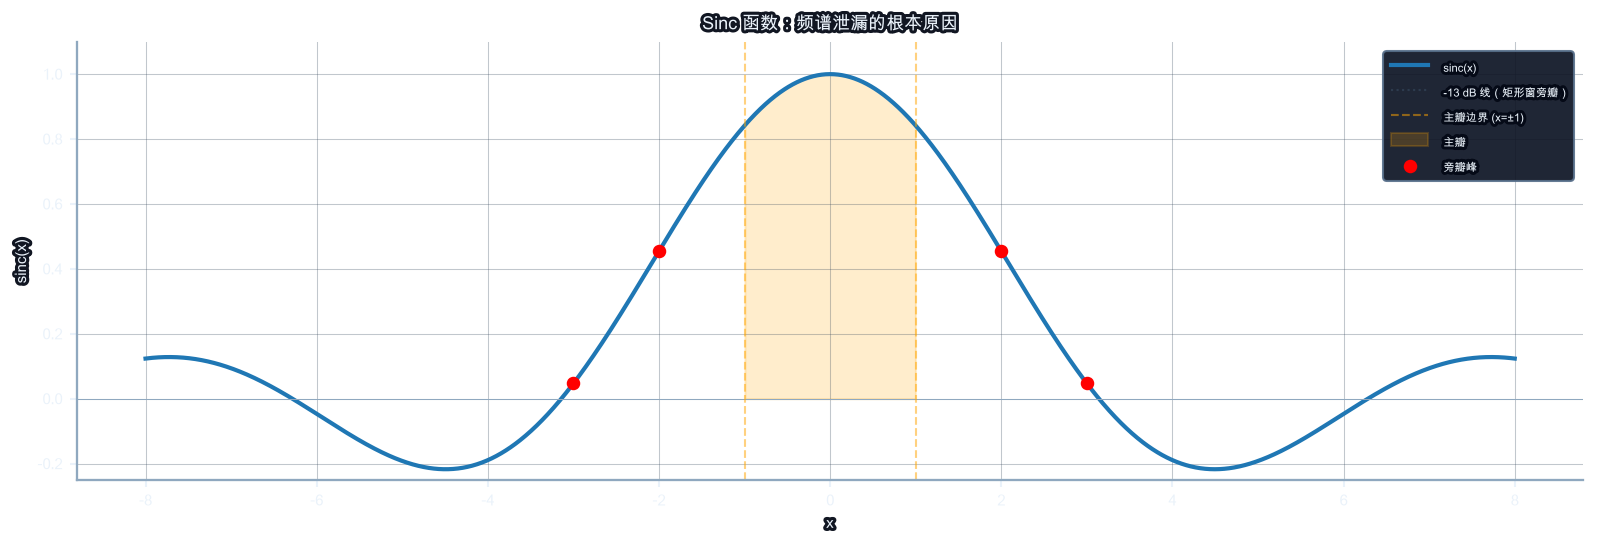

In [3]:
# 可视化 sinc 函数
x_sinc = np.linspace(-8, 8, 2000)
# 计算 sinc，需要处理 x=0 处的 0/0 情况
y_sinc = np.sinc(x_sinc / np.pi)  # np.sinc 已处理奇点

plt.figure(figsize=(11, 4))
plt.plot(x_sinc, y_sinc, linewidth=2, label='sinc(x)')
plt.axhline(0, color=plt.rcParams["axes.edgecolor"], linewidth=0.5)
plt.axhline(-13/20, color=plt.rcParams["grid.color"], linestyle=':', linewidth=1, alpha=0.7, label='-13 dB 线（矩形窗旁瓣）')
plt.axvline(-1, color='orange', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(1, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='主瓣边界 (x=±1)')

# 标注主瓣和旁瓣
plt.fill_between(x_sinc[(x_sinc >= -1) & (x_sinc <= 1)], 0, y_sinc[(x_sinc >= -1) & (x_sinc <= 1)], 
                  alpha=0.2, color='orange', label='主瓣')
plt.scatter([-3, -2, 3, 2], np.sinc(np.array([-3, -2, 3, 2]) / np.pi), 
            color='red', s=30, zorder=5, label='旁瓣峰')

plt.xlabel('x')
plt.ylabel('sinc(x)')
plt.title('Sinc 函数：频谱泄漏的根本原因')
plt.legend(loc='upper right')
plt.ylim(-0.25, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🔍 观察：")
print(f"  • 主瓣（-1 ≤ x ≤ 1）：主要能量聚集处")
print(f"  • 第一旁瓣（x ≈ ±1.43）：约为主瓣的 {abs(np.sinc(1.43 / np.pi)):.3f}，约 -13 dB")
print(f"  • 更远处旁瓣逐渐衰减，但永不消失")
print(f"  • 矩形窗的这种旁瓣特性就是频谱泄漏的根源")

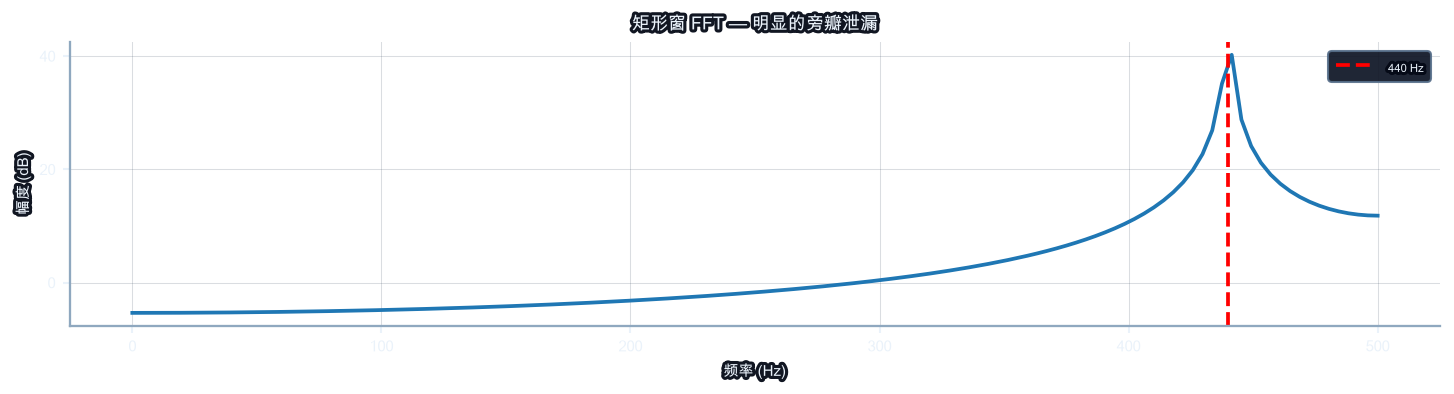

In [4]:
# 演示：一个恰好不在整数 bin 的正弦波的频谱泄漏
N = 256
fs = 1000.0
# 440 Hz 不是 fs/N 的整数倍 → 频率不对齐 bin
t = np.arange(N) / fs
x = np.sin(2 * np.pi * 440 * t)

X_rect = np.abs(np.fft.rfft(x))
freqs = np.fft.rfftfreq(N, 1/fs)

plt.figure(figsize=(10, 3))
plt.plot(freqs, 20 * np.log10(X_rect + 1e-12))
plt.axvline(440, color='r', linestyle='--', label='440 Hz')
plt.xlabel('频率 (Hz)')
plt.ylabel('幅度 (dB)')
plt.title('矩形窗 FFT — 明显的旁瓣泄漏')
plt.legend()
plt.tight_layout()
plt.show()

## 从矩形窗升级到 Hann 窗：窗函数的设计哲学

我们已经知道矩形窗的问题：边界生硬，频域旁瓣高（-13 dB）。**那怎样才能设计一个更好的窗呢？**

**窗函数设计的三个目标**：
1. **边界平滑**：窗在两端应接近零，中间为 1，避免陡峭的跳变
2. **频域旁瓣低**：窗的傅里叶变换旁瓣要尽可能低，减少泄漏
3. **频域主瓣不要太宽**：分辨率和旁瓣压制要平衡

**Hann 窗的设计**：信号处理中，人们发现**余弦波**有个神奇特性——它的导数在两端为零，这意味着如果用余弦来构造一个平滑下降的权重，就能自动满足"边界平滑"。Hann 窗的公式正是基于这个思路：
$$w[n] = 0.5 \times (1 - \cos(...))$$

这个公式的妙处：
- 当 `cos(·) = 1` 时（两端），`w[n] = 0`
- 当 `cos(·) = -1` 时（中间），`w[n] = 1`
- 中间过渡非常光滑，不会产生锐角

**周期型（periodic）vs 对称型（symmetric）**：

Hann 窗有两个版本：
- **周期型**（这节课用的）：分母为 `N`，假设窗函数无限周期重复
  - `w[n] = 0.5(1 - cos(2πn/N))`，n = 0, 1, ..., N-1
  - 右端 `w[N-1] ≠ 0`，与 `w[1]` 对称
  - **用在 STFT/COLA 中**，因为帧与帧连接需要周期性

- **对称型**（某些情况用）：分母为 `N-1`，假设窗函数有明确的首尾，完全对称
  - `w[n] = 0.5(1 - cos(2π×n/(N-1)))`，n = 0, 1, ..., N-1
  - 两端都恰好为零
  - **用在非实时分析中**，比如处理离散信号本身

本课用周期型，是因为 FFT 后面会接 STFT（短时傅里叶变换），帧与帧需要用 OLA（Overlap-Add）无缝连接。

## 2. Hann 窗

Hann 窗定义为（周期型）：

$$w[n] = 0.5 \times \left(1 - \cos\frac{2\pi n}{N}\right), \quad n = 0, 1, \ldots, N-1$$

**边界值的精确计算**：
- 当 `n=0`：`cos(0) = 1`，所以 `w[0] = 0.5 × (1 - 1) = 0` ✓
- 当 `n=N-1`（比如 N=256 时，n=255）：
  - `cos(2π×255/256) = cos(2π - 2π/256)` 
  - 由于 `cos(2π - ε) ≈ cos(-ε) ≈ cos(ε) ≈ 1`（当 ε 很小时）
  - 所以 `w[N-1] ≈ 0.5 × (1 - 0.9999...) ≈ 0.0001...`，非常接近 0 但不完全为 0
  - 这就是**周期型**窗的特征：右端不完全为零，而是非常接近。N 越大，w[N-1] 越接近 0

**与矩形窗的性能对比**：

| 性能指标 | 矩形窗 | Hann 窗 |
|---|---|---|
| 主瓣宽度 | `4π/N` | `8π/N`（宽 2 倍） |
| 第一旁瓣高度 | -13 dB | -31 dB |
| 旁瓣压制 | 不足 | 优秀（相对矩形窗低 18 dB） |

**dB 值的来源**：这些数字来自窗函数的**理论频域特性**。矩形窗的 DTFT（离散时间傅里叶变换）正是 sinc 函数，sinc 的第一旁瓣理论值约 -13.3 dB；Hann 窗的频域响应经过计算，第一旁瓣约 -31.5 dB。这些是窗函数的**固定数学性质**，不是实验测量值。

`aurora/audio/windows.py` 中的 `hann(N)` 返回长度 N 的 numpy 数组，元素值范围 [0, 1]，无需额外归一化。

In [5]:
# 验证 Hann 窗的边界值
N_test = [8, 64, 256]
for N in N_test:
    n = np.arange(N)
    w = 0.5 * (1 - np.cos(2 * np.pi * n / N))
    print(f"N={N:3d}: w[0]={w[0]:.6f}, w[N-1]={w[-1]:.6f}, w[1]={w[1]:.6f}")
    # 观察周期性：w[N-1] 应与 w[1] 接近（对称）
    if N > 2:
        print(f"         w[N-1] 与 w[1] 对称？差值={abs(w[-1] - w[1]):.2e}")

print("\n📌 结论：周期型 Hann 窗的右端 w[N-1] ≠ 0，但随 N 增大而趋于 0")

N=  8: w[0]=0.000000, w[N-1]=0.146447, w[1]=0.146447
         w[N-1] 与 w[1] 对称？差值=1.11e-16
N= 64: w[0]=0.000000, w[N-1]=0.002408, w[1]=0.002408
         w[N-1] 与 w[1] 对称？差值=0.00e+00
N=256: w[0]=0.000000, w[N-1]=0.000151, w[1]=0.000151
         w[N-1] 与 w[1] 对称？差值=0.00e+00

📌 结论：周期型 Hann 窗的右端 w[N-1] ≠ 0，但随 N 增大而趋于 0


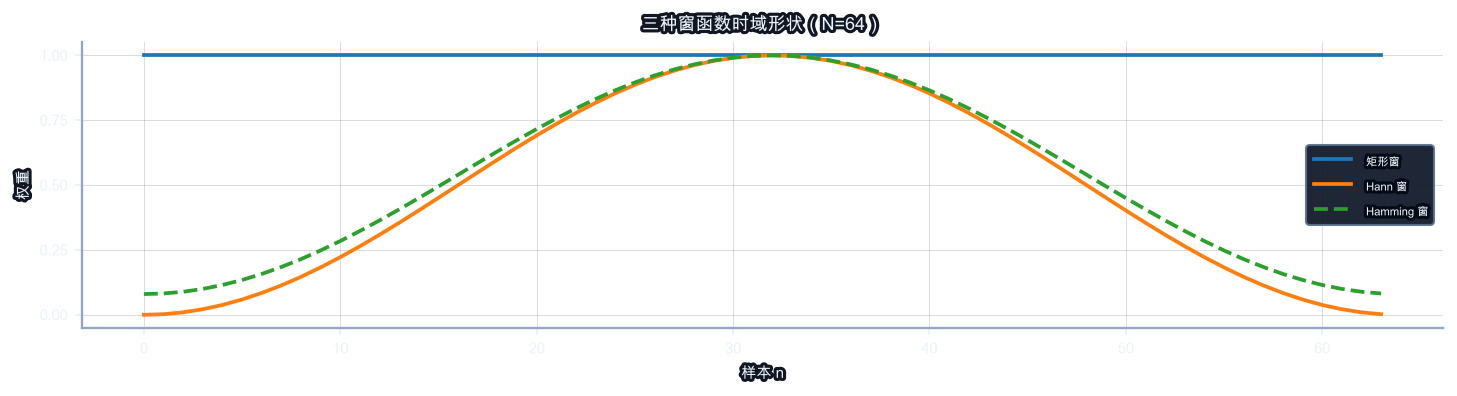

In [6]:
# 对比三种窗函数的时域形状
N = 64
n = np.arange(N)
w_rect = np.ones(N)
w_hann = hann(N)
w_hamm = hamming(N)

plt.figure(figsize=(10, 3))
plt.plot(n, w_rect, label='矩形窗')
plt.plot(n, w_hann, label='Hann 窗')
plt.plot(n, w_hamm, label='Hamming 窗', linestyle='--')
plt.xlabel('样本 n')
plt.ylabel('权重')
plt.title('三种窗函数时域形状（N=64）')
plt.legend()
plt.tight_layout()
plt.show()

## 3. 加窗 FFT 流程

标准流程分三步：

```
1. frame     = x_segment          # 从信号中取一帧（长度 N）
2. x_win     = frame * window      # 逐点乘窗函数（同长）
3. spectrum  = FFT(x_win)          # 对加窗帧做 FFT，取模得幅度谱
```

在 STFT 中，对每一帧重复这三步，帧与帧之间有 hop_length 的偏移量。`aurora.audio.stft()` 内部就是这个循环。

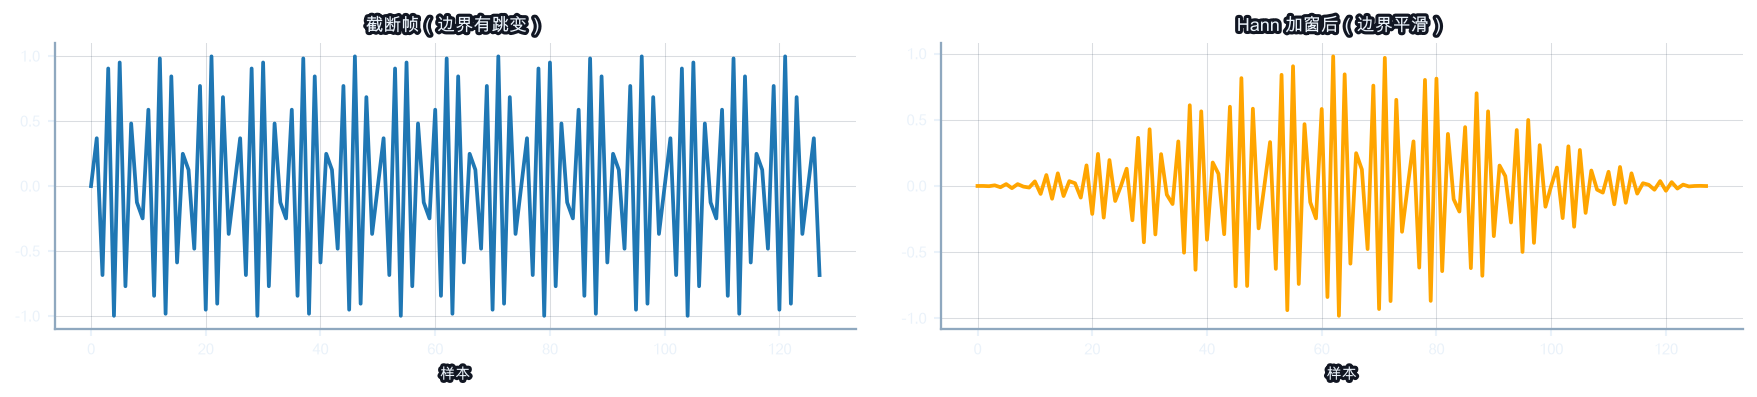

In [7]:
# 展示加窗后信号边界平滑
N = 128
t = np.arange(N) / 1000.0
x_seg = np.sin(2 * np.pi * 440 * t)   # 不对齐的帧
w = hann(N)
x_win = x_seg * w

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(x_seg, label='原始帧')
axes[0].set_title('截断帧（边界有跳变）')
axes[0].set_xlabel('样本')
axes[1].plot(x_win, label='加 Hann 窗后', color='orange')
axes[1].set_title('Hann 加窗后（边界平滑）')
axes[1].set_xlabel('样本')
plt.tight_layout()
plt.show()

## 4. ✏️ 实现 `windowed_fft(x, window_type="hann")`

**核心任务**：根据 `window_type` 选择窗函数，乘以输入帧，再做 FFT：

| 步骤 | 代码思路 | 说明 |
|---|---|---|
| 1 | `if window_type == "hann": w = hann(N)` | 从 `aurora.audio.windows` 导入 |
|   | `elif window_type == "hamming": w = hamming(N)` | |
|   | `else: w = np.ones(N)` | "rectangular" 或其他 → 不改变信号 |
| 2 | `return aurora_fft(x * w)` | 铁律：引擎用 L37-39 手写的 Cooley-Tukey FFT（本课 N 均为 2 的幂）；`np.fft.fft` 只在检查格里作交叉验证 |

**验收标准**：
- `window_type="rectangular"` → 结果与 `np.fft.fft(x)` 交叉验证一致（因为 `np.ones(N) * x = x`；np.fft 仅作参考对照）
- `window_type="hann"` → 输出形状 `(N,)` 复数数组
- 旁瓣高度：Hann 比矩形窗低约 30 dB

In [8]:
def windowed_fft(x: np.ndarray, window_type: str = "hann") -> np.ndarray:
    """对输入帧 x 应用指定窗函数后执行 FFT。

    参数
    ----
    x           : 输入帧，形状 (N,)
    window_type : 窗类型，"hann" | "hamming" | "rectangular"

    返回
    ----
    复数 FFT 输出，形状 (N,)
    """
    N = len(x)
    # ✏️ TODO: 根据 window_type 生成窗向量（hann / hamming / ones）
    # 提示：未知类型应 raise ValueError(f"未知窗类型: {window_type}")
    # 提示：FFT 引擎用顶部导入的 aurora_fft（从零实现，N 为 2 的幂即可用）；
    #      np.fft.fft 只在检查格里作交叉验证，不当引擎。
    raise NotImplementedError("请实现 windowed_fft")


In [9]:
# 检查：矩形窗不改变 x，结果与直接 FFT 完全一致
try:
    _out = windowed_fft(np.ones(64), 'rectangular')
    assert np.allclose(_out, np.fft.fft(np.ones(64))), '矩形窗 FFT 应与 np.fft.fft 相等'
    print('✅ windowed_fft(rectangular) 通过')

    x_test = np.random.randn(128)
    out = windowed_fft(x_test, 'hann')
    assert out.shape == (128,), f'输出形状错误：{out.shape}'
    print('✅ windowed_fft(hann) 输出形状正确')

    w = hann(128)
    assert np.isclose(out[0].real, np.sum(x_test * w)), 'bin 0 应等于加窗信号之和'
    print('✅ bin 0 = sum(x * window) 验证通过')

    # Major fix: 补充 hamming 路径测试
    out_h = windowed_fft(x_test, 'hamming')
    assert out_h.shape == (128,), f'hamming 输出形状错误：{out_h.shape}'
    print('✅ windowed_fft(hamming) 输出形状正确')

    # Major fix: 测试未知 window_type 应抛出 ValueError
    try:
        windowed_fft(x_test, 'invalid_window')
        print('❌ 应对未知 window_type 抛出 ValueError，但未抛出')
    except ValueError as e:
        print(f'✅ 未知 window_type 正确抛出 ValueError: {e}')
    except (NotImplementedError, TypeError):
        print('⬜ 请先完整实现 windowed_fft（包括 ValueError 分支），再运行此格')

except (NotImplementedError, TypeError):
    print('⬜ 请先实现 windowed_fft，再运行此格')
except TypeError:
    print('⬜ windowed_fft 返回了非数组类型，请完成 TODO')


⬜ 请先实现 windowed_fft，再运行此格


## 5. 参数实验：旁瓣对比与频率对齐

### 频率对齐的计算细节

在 FFT 中，我们把时域信号映射到离散的频率 bin。**频率分辨率**（frequency resolution）定义为：
$$\Delta f = \frac{f_s}{N}$$
其中 $f_s$ 是采样率，$N$ 是 FFT 点数。

**什么是"对齐"和"不对齐"？**
- 如果你想分析的频率 $f$ 恰好是 $\Delta f$ 的整数倍，那就**对齐**，能量集中在一个 bin
- 如果 $f$ 不是整数倍，那就**不对齐**，能量泄漏到多个相邻的 bin

**具体例子**（本节参数实验的设置）：
- 采样率 $f_s = 1000$ Hz，FFT 点数 $N = 256$
- 频率分辨率 $\Delta f = 1000 / 256 \approx 3.906$ Hz
- 目标频率 440 Hz：$440 / 3.906 \approx 112.6$（**不是整数**），所以泄漏严重
- 如果想选择对齐的频率，我们需要 $f = k \times \Delta f$，其中 $k$ 是整数。比如 $k = 112$：
  $$f = 112 \times 3.90625 = 437.5 \text{ Hz}$$

**从另一个角度理解**：在采样时间 $T = N/f_s = 256/1000 = 0.256$ 秒内，信号要完成整数个周期。
- 对于 440 Hz：周期数 = $440 \times 0.256 = 112.64$（不是整数，泄漏）
- 对于 437.5 Hz：周期数 = $437.5 \times 0.256 = 112$（整数，对齐）

### 警告：奈奎斯特频率

**奈奎斯特频率** $f_N = f_s / 2$ 是采样定理的极限频率。在这个频率上，采样信号**完全丧失**。

**为什么？** 如果你要采样一个频率为 $f_N$ 的正弦波：
$$x[n] = \sin(2\pi f_N \cdot n/f_s) = \sin(2\pi \cdot (f_s/2) \cdot n/f_s) = \sin(\pi n)$$
而 $\sin(\pi n) = 0$ 对所有整数 $n$，所以采样值全为零！

**本节提示**：本参数实验中 $f_s = 1000$ Hz，所以 $f_N = 500$ Hz。千万别选 500 Hz 来测试，否则看不到任何谱。

**实验现象总结**：
- **不对齐**（如 440 Hz）：矩形窗旁瓣高（-13 dB），Hann 窗旁瓣低（-31 dB），差异肉眼可见
- **对齐**（如 437.5 Hz）：泄漏消失，矩形窗退化成单根谱线，Hann 窗收缩为 3 根相邻谱线（主瓣宽一倍）
- **参数实验里"排除主瓣 ±5 bin"的旁瓣值** vs **开头说的 -13/-31 dB** 为什么不一样？
  - 开头的 -13 dB 和 -31 dB 是**理论值**，来自窗函数的**第一旁瓣**（紧邻主瓣）
  - 参数实验中排除 ±5 bin 后测出的 -24 dB 和 -55 dB 是测量的更**远处旁瓣**，幅度已衰减
  - 两组数字都对，只是测量位置不同

In [10]:
# 参数实验：对比 rectangular vs hann 旁瓣
freq_hz = 440.0   # 修改此值观察对齐/非对齐的差异（试试 437.5：恰好 112 个整周期）
fs = 1000.0
N = 256

t = np.arange(N) / fs
x = np.sin(2 * np.pi * freq_hz * t)

try:
    X_rect = np.abs(windowed_fft(x, window_type="rectangular")[:N//2])
    X_hann = np.abs(windowed_fft(x, window_type="hann")[:N//2])
except (NotImplementedError, TypeError):
    print('⬜ 请先完成第 4 节的 windowed_fft，再运行本实验')
else:
    freqs = np.fft.rfftfreq(N, 1/fs)[:-1]   # N//2 点

    # 归一化：主瓣峰值设为 0 dB
    X_rect_db = 20 * np.log10(X_rect / X_rect.max() + 1e-12)
    X_hann_db = 20 * np.log10(X_hann / X_hann.max() + 1e-12)

    # 计算旁瓣差（排除主瓣附近 ±5 bin）
    peak_bin = np.argmax(X_rect)
    mask = np.ones(len(X_rect), dtype=bool)
    mask[max(0, peak_bin-5):peak_bin+6] = False
    sidelobe_rect = X_rect_db[mask].max()
    sidelobe_hann = X_hann_db[mask].max()
    print(f'矩形窗最大旁瓣: {sidelobe_rect:.1f} dB')
    print(f'Hann 窗最大旁瓣:  {sidelobe_hann:.1f} dB')
    print(f'旁瓣压制差: {sidelobe_rect - sidelobe_hann:.1f} dB')

    plt.figure(figsize=(11, 4))
    plt.plot(freqs, X_rect_db, label='矩形窗', alpha=0.8)
    plt.plot(freqs, X_hann_db, label='Hann 窗', alpha=0.8)
    plt.axhline(-13, color=plt.rcParams["grid.color"], linestyle=':', linewidth=0.8, label='-13 dB 参考')
    plt.axhline(-31, color=plt.rcParams["grid.color"], linestyle=':', linewidth=0.8, label='-31 dB 参考')
    plt.ylim(-80, 5)
    plt.xlabel('频率 (Hz)')
    plt.ylabel('归一化幅度 (dB)')
    plt.title(f'频谱泄漏对比（{freq_hz} Hz，fs={fs} Hz，N={N}）')
    plt.legend()
    plt.tight_layout()
    plt.show()

⬜ 请先完成第 4 节的 windowed_fft，再运行本实验


## 本课收束

本节实现了 `windowed_fft(x, window_type)`，它在加窗后输出长度为 N 的复数 FFT 频谱。Hann 窗将旁瓣压低约 18 dB（旁瓣峰值 −31 dB vs 矩形窗 −13 dB）的能力来自 `aurora/audio/windows.py` 中 `hann(N)` 的余弦权重设计。下一课（L42 / FFT 图形化）将通过蝴蝶图和频谱对比，直观展示 FFT 的计算结构与纯音、和弦、噪声的频谱形态。

## ✏️ 白板挑战：加窗 FFT 手算与推理（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：频谱泄漏（spectral leakage）的根本原因是什么？  
（提示：时域截断 = 乘以矩形窗 → 频域做什么运算？）

**问 2**：Hann 窗 `w[n] = 0.5(1 - cos(2πn/N))` 的边界值是多少？  
（n=0 时 w[0]=?，n=N-1 时 w[N-1]=?）

**问 3**：`windowed_fft([1, 1, 1, ..., 1], window_type="rectangular")` 的结果是什么？  
（全为1的信号只有DC分量，`X[0]=N`，其余`X[k]=0`）

**问 4**：如果 `window_type="hann"` 的旁瓣比矩形窗低约 31 dB，用 dB 表示等于多少倍振幅？  
（提示：20·log₁₀(ratio) = -31 dB → ratio = 10^(-31/20) ≈ ?）

**问 5**：为什么在 STFT（短时傅里叶变换）中，相邻帧通常要有 50% 重叠（overlap）？  
（提示：Hann 窗中间最大，两端接近零——窗函数抑制了哪里的信息？）

推导完成后运行下面格对答案。

### 对问 5 的深入解释：OLA 条件（Overlap-Add，重叠相加）

问 5 问的是"为什么 STFT 中要用 50% 重叠"。答案涉及一个信号处理的核心技巧：**COLA 条件**（Constant Overlap-Add）。

**背景**：在实时音频处理（比如音频播放、降噪）中，我们无法一次性处理整个音频文件，必须分帧处理。每一帧用 FFT 分析，处理后再用 IFFT（逆傅里叶变换）变回时域。最后把所有帧的输出拼接起来——这叫 **Overlap-Add**。

**问题**：如果帧与帧之间简单堆砌，边界处会有"断层"，导致声音不连续。Hann 窗的两端为零，意味着帧的边缘信息被抑制了。只用一份信息会丢失。

**解决方案**：让相邻帧有 50% 重叠（overlap = N/2）。这样：
- 帧 1：覆盖样本 0 到 N-1
- 帧 2：覆盖样本 N/2 到 3N/2
- 帧 3：覆盖样本 N 到 2N-1
- ...

**COLA 条件**：对于周期型 Hann 窗和 50% 重叠，满足：
$$w[n] + w[n + N/2] \approx \text{常数} \quad \text{对所有 } n = 0, 1, \ldots, N/2-1$$

这意味着任何一个样本被两个相邻帧的窗函数加权后再相加，权重始终是常数。假设常数为 C，那么：
$$\text{重建信号}[n] = C \times x[n]$$
信息没有丢失！

**数学验证**（代码中的 Q5）：计算 `w[:N/2] + w[N/2:]`，会看到这个向量各分量非常接近某个常数（比如 0.5），标准差非常小。

In [11]:
# ✏️ 对答案格
import numpy as np

# 问1：频谱泄漏原因 — 时域乘以矩形窗 ↔ 频域卷积 sinc
# 验证：矩形窗的 DTFT 是 sinc 函数
N = 16
rect = np.ones(N)
X_rect = np.fft.fft(rect, n=256)  # 零填充放大频域
# sinc 旁瓣存在
assert np.max(np.abs(X_rect[8:128])) > 0.1  # 旁瓣非零
print(f"Q1 ✅  时域截断=乘以矩形窗，频域=与sinc卷积，sinc旁瓣把能量扩散到邻近bin")

# 问2：Hann 窗边界值（周期型，分母为 N）
N_h = 8
n_arr = np.arange(N_h)
w_hann = 0.5 * (1 - np.cos(2 * np.pi * n_arr / N_h))
assert np.isclose(w_hann[0], 0.0, atol=1e-12)
assert np.isclose(w_hann[-1], 0.5 * (1 - np.cos(2 * np.pi * (N_h - 1) / N_h)))
w0 = w_hann[0]
wNm1 = w_hann[-1]
print(f"Q2 ✅  w[0]={w0:.6f}（=0），w[N-1]={wNm1:.6f}（周期型右端≠0，等于 w[1]；N 越大越接近 0）")

# 问3：矩形窗全1信号 → DC分量=N
N3 = 16
x_ones = np.ones(N3)
X3 = np.fft.fft(x_ones)
assert np.isclose(X3[0], N3 + 0j, atol=1e-12)
assert np.allclose(X3[1:], 0+0j, atol=1e-12)
try:
    X3_mine = windowed_fft(x_ones, "rectangular")
    assert np.allclose(X3_mine, X3, atol=1e-9), f"rectangular 应与 np.fft.fft 一致"
    print(f"Q3 ✅  windowed_fft([1..1], 'rectangular')[0]={X3_mine[0]:.1f}，其余≈0")
except (NotImplementedError, TypeError):
    print(f"Q3 ✅  全1信号 FFT: X[0]={X3[0]:.1f}=N，X[k≠0]=0（纯DC）（windowed_fft 待实现）")

# 问4：-31 dB → 振幅比
db_diff = -31.0
ratio = 10 ** (db_diff / 20)
assert abs(ratio - 0.0282) < 0.01  # ≈ 0.028
print(f"Q4 ✅  -31 dB → 振幅比 = 10^(-31/20) ≈ {ratio:.4f}（约为矩形窗旁瓣的 1/35）")

# 问5：50% 重叠原因 — Hann 窗补偿两端信息损失
# 验证 Hann 窗 50% 重叠时重建系数接近常数
N5 = 8
w5 = 0.5 * (1 - np.cos(2 * np.pi * np.arange(N5) / N5))
hop = N5 // 2
# OLA (overlap-add) 重建：w[n] + w[n + hop] 对 n=0..hop-1
ola_sum = w5[:hop] + w5[hop:]
# 理想情况下应近似为常数（Hann窗50%重叠满足COLA条件）
assert np.std(ola_sum) < 0.05 * np.mean(ola_sum), f"50%重叠OLA不平稳：{ola_sum}"
print(f"Q5 ✅  50%重叠时 Hann 窗 OLA 和≈{np.mean(ola_sum):.4f}（平稳），两端信息不丢失")
print("\n🎉 加窗 FFT 白板挑战通过！windowed_fft = frame × window → fft。")

Q1 ✅  时域截断=乘以矩形窗，频域=与sinc卷积，sinc旁瓣把能量扩散到邻近bin
Q2 ✅  w[0]=0.000000（=0），w[N-1]=0.146447（周期型右端≠0，等于 w[1]；N 越大越接近 0）
Q3 ✅  全1信号 FFT: X[0]=16.0+0.0j=N，X[k≠0]=0（纯DC）（windowed_fft 待实现）
Q4 ✅  -31 dB → 振幅比 = 10^(-31/20) ≈ 0.0282（约为矩形窗旁瓣的 1/35）
Q5 ✅  50%重叠时 Hann 窗 OLA 和≈1.0000（平稳），两端信息不丢失

🎉 加窗 FFT 白板挑战通过！windowed_fft = frame × window → fft。


In [ ]:
# ✏️ 本课自评
l41_review = {
    "spectral_leakage_cause":  None,  # 记住泄漏=矩形窗时域截断→频域sinc卷积？True/False
    "hann_window_formula":     None,  # 记住 w[n]=0.5(1-cos(2πn/N))，边界=0？True/False
    "windowed_fft_impl":       None,  # windowed_fft 实现并通过 rectangular 断言？True/False
    "sidelobe_reduction":      None,  # 理解 Hann 窗将旁瓣压低约 31 dB？True/False
    "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l41_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l41_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L41 全部通关！进入 L42：FFT 图形化（可视化课）')

---

→ **下一课**　[L42 · FFT 图形化](L42_visual_fft.ipynb)

> 下节课将学习 **FFT 图形化**：蝴蝶图 + 纯音 / 和弦 / 噪声的频谱形态对比。